In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv('/content/drive/MyDrive/cosmic.csv')
df = df.dropna(subset=['Prediction'])
df.sample(5)

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Magnetic Field Strength,Radiation Levels,Atmospheric Composition Index,Prediction
3861,0.403916,0.290030,1.823729,2.090811,1.682164,-3.597182,0.506501,Category_7,NaN,-0.905549,6.0
42966,0.064482,-1.890909,-2.396976,-1.424129,2.165113,-2.599367,1.110028,Category_10,Category_10,1.133335,3.0
42784,-2.410936,0.685235,0.825408,0.220330,-0.109788,1.383260,0.058791,Category_9,Category_12,-0.592471,7.0
50093,2.689714,NaN,3.812165,1.099182,2.115676,-3.080471,0.015064,Category_10,Category_11,-0.251298,6.0
29816,-0.964948,-1.303258,0.401738,-0.000445,-0.984922,-1.654460,-1.893006,Category_13,Category_8,-1.268333,3.0


In [9]:
df.isnull().sum()

,0
Atmospheric Density,2842
Surface Temperature,2896
Gravity,2826
Water Content,2936
Mineral Abundance,2784
Orbital Period,2855
Proximity to Star,2786
Magnetic Field Strength,2941
Radiation Levels,2859
Atmospheric Composition Index,2795


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56961 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Atmospheric Density            54119 non-null  float64
 1   Surface Temperature            54065 non-null  float64
 2   Gravity                        54135 non-null  float64
 3   Water Content                  54025 non-null  float64
 4   Mineral Abundance              54177 non-null  float64
 5   Orbital Period                 54106 non-null  float64
 6   Proximity to Star              54175 non-null  float64
 7   Magnetic Field Strength        54020 non-null  object 
 8   Radiation Levels               54102 non-null  object 
 9   Atmospheric Composition Index  54166 non-null  float64
 10  Prediction                     56961 non-null  float64
dtypes: float64(9), object(2)
memory usage: 5.2+ MB


In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns=['Prediction'], axis=1), df['Prediction'], test_size=0.2, random_state=42)

In [12]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(45568, 10)
(11393, 10)
(45568,)
(11393,)


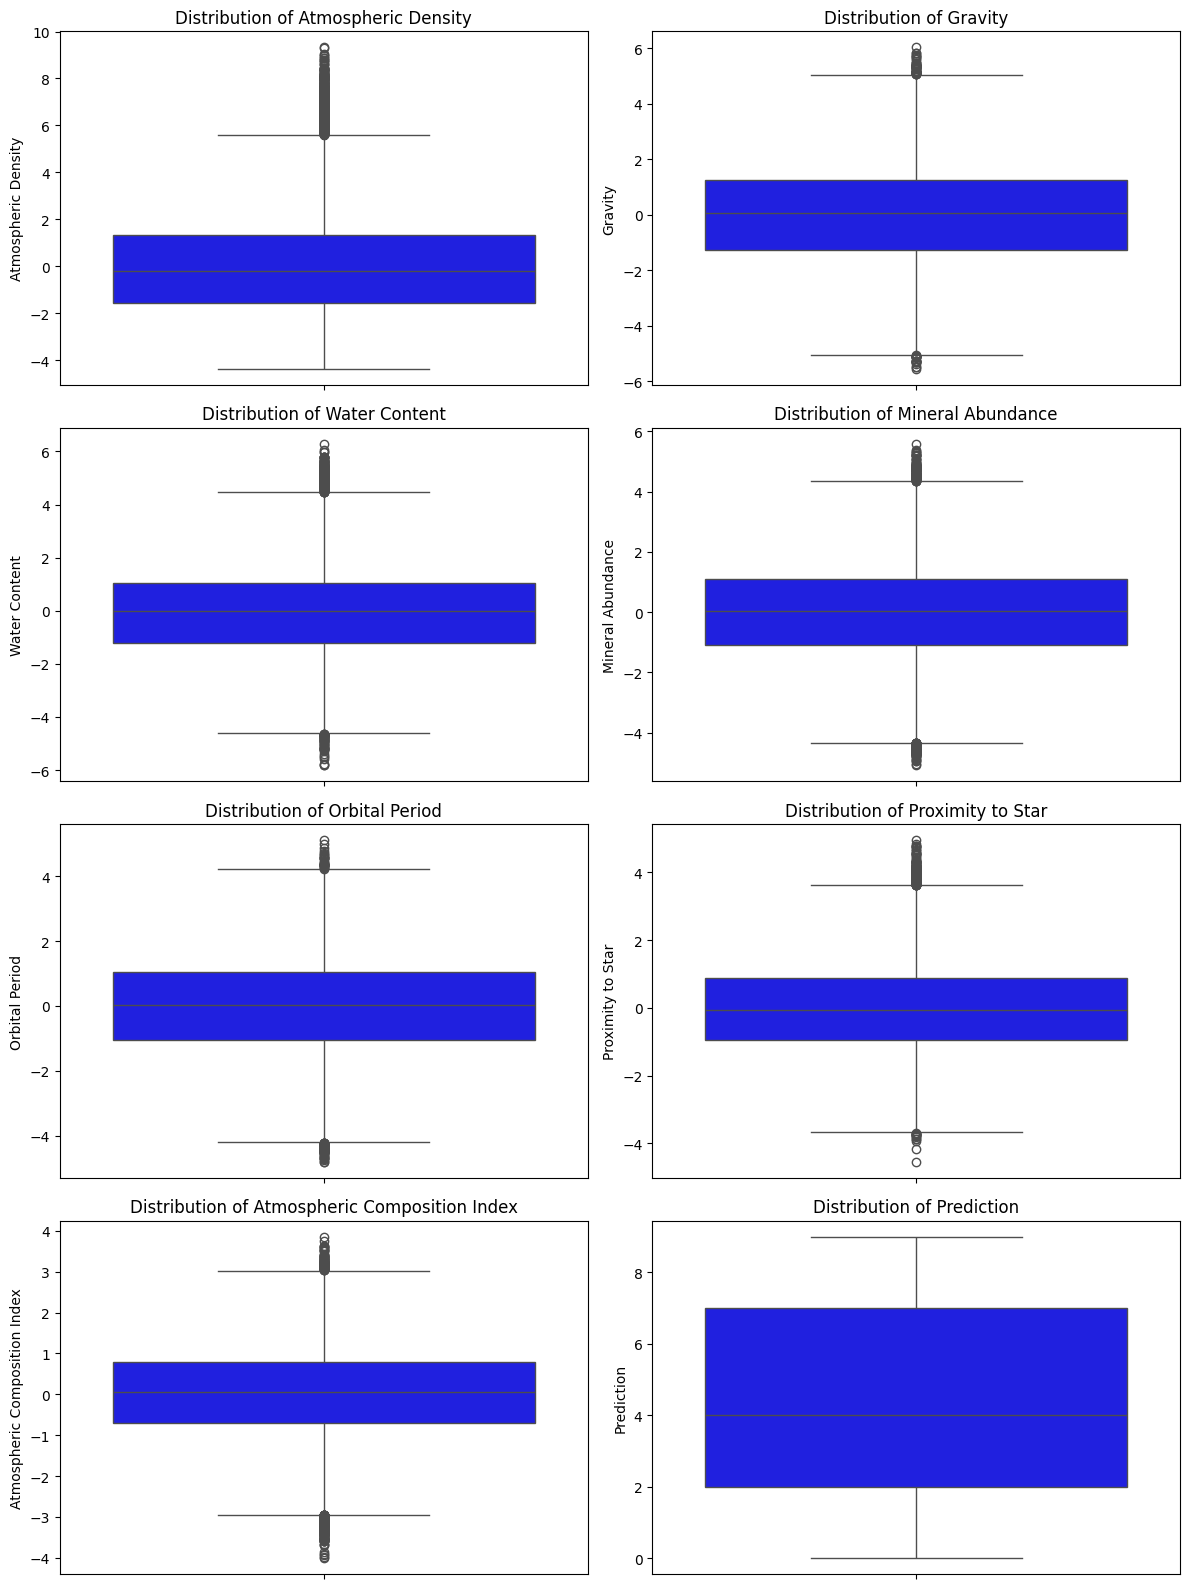

In [13]:
import math

columns =['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',
'Prediction']

num_colss = 2
num_rowss = math.ceil(len(columns) / num_colss)

fig, axes = plt.subplots(num_rowss, num_colss, figsize=(12, num_rowss * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(df[col],  color='blue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Impute values

In [14]:
columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index']

In [15]:
#imputing using median
from sklearn.impute import SimpleImputer
# si_median = SimpleImputer(strategy='median')

from sklearn.impute import KNNImputer
knn = KNNImputer()
x_train[columns] = knn.fit_transform(x_train[columns])
x_test[columns] = knn.transform(x_test[columns])


# df[columns] = si_median.fit_transform(df[columns])

In [16]:
freq_encode_cols = ['Radiation Levels' , 'Magnetic Field Strength']

for col in freq_encode_cols:
    freq_map = x_train[col].value_counts().to_dict()
    x_train[col] = x_train[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_train['Magnetic Field Strength'] = si_mode.fit_transform(x_train[['Magnetic Field Strength']])
x_train['Radiation Levels'] = si_mode.fit_transform(x_train[['Radiation Levels']])



freq_encode_cols = ['Radiation Levels' , 'Magnetic Field Strength']

for col in freq_encode_cols:
    freq_map = x_test[col].value_counts().to_dict()
    x_test[col] = x_test[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_test['Magnetic Field Strength'] = si_mode.fit_transform(x_test[['Magnetic Field Strength']])
x_test['Radiation Levels'] = si_mode.fit_transform(x_test[['Radiation Levels']])

In [17]:
x_train.isnull().sum()

,0
Atmospheric Density,0
Surface Temperature,0
Gravity,0
Water Content,0
Mineral Abundance,0
Orbital Period,0
Proximity to Star,0
Magnetic Field Strength,0
Radiation Levels,0
Atmospheric Composition Index,0


Remove outliars

In [18]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(45568, 10)
(11393, 10)
(45568,)
(11393,)


Removing Skewness

In [19]:
from sklearn.preprocessing import PowerTransformer
columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index']

pt = PowerTransformer(method='yeo-johnson')
for col in columns:
    x_train[col] = pt.fit_transform(x_train[[col]])


pt = PowerTransformer(method='yeo-johnson')
for col in columns:
    x_test[col] = pt.fit_transform(x_test[[col]])

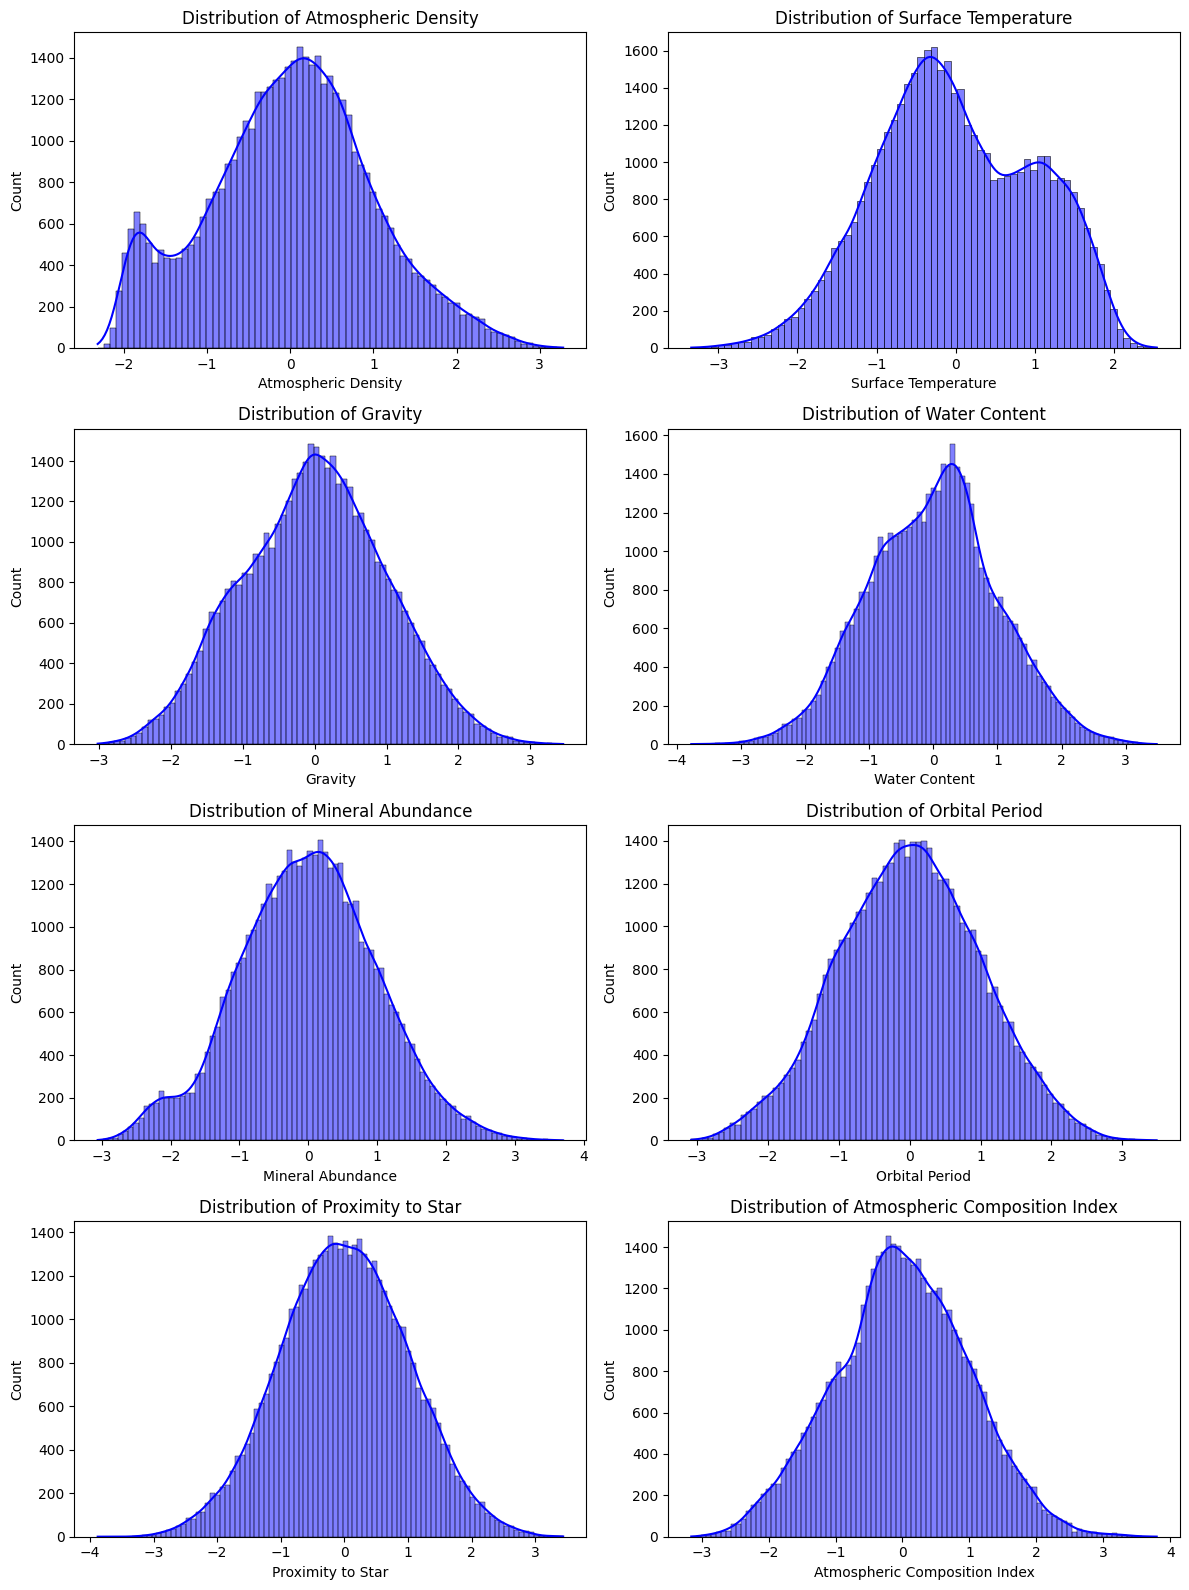

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index']

num_colss = 2
num_rowss = math.ceil(len(columns) / num_colss)

fig, axes = plt.subplots(num_rowss, num_colss, figsize=(12, num_rowss * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(x_train[col], kde=True, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [21]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

# Store original categorical columns
train_magnetic = x_train['Magnetic Field Strength'].copy()
train_radiation = x_train['Radiation Levels'].copy()
test_magnetic = x_test['Magnetic Field Strength'].copy()
test_radiation = x_test['Radiation Levels'].copy()

# Transform numerical columns
x_train_scaled = mms.fit_transform(x_train[columns])
x_test_scaled = mms.transform(x_test[columns])

# Convert back to DataFrame with proper indices
x_train = pd.DataFrame(x_train_scaled, columns=columns, index=train_magnetic.index)
x_test = pd.DataFrame(x_test_scaled, columns=columns, index=test_magnetic.index)

# Add back categorical columns
x_train['Magnetic Field Strength'] = train_magnetic
x_train['Radiation Levels'] = train_radiation
x_test['Magnetic Field Strength'] = test_magnetic
x_test['Radiation Levels'] = test_radiation

# Display results
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
x_train.head()

Training data shape: (45568, 10)
Test data shape: (11393, 10)


,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Atmospheric Composition Index,Magnetic Field Strength,Radiation Levels
43202,0.432370,0.835185,0.363699,0.437912,0.291417,0.458272,0.731366,0.536320,952.0,6328.0
36025,0.345354,0.735400,0.611787,0.611897,0.442217,0.350421,0.514555,0.289321,4630.0,3970.0
29732,0.638509,0.525505,0.305496,0.453695,0.123488,0.643020,0.480507,0.590101,247.0,6328.0
7995,0.440501,0.602484,0.617435,0.559629,0.405513,0.301295,0.491308,0.242000,4630.0,1317.0
34796,0.051050,0.403344,0.459614,0.567467,0.295718,0.418230,0.605014,0.414115,6723.0,6192.0


Encoding Categorical Features

In [22]:
freq_encode_cols = ['Radiation Levels' , 'Magnetic Field Strength']

for col in freq_encode_cols:
    freq_map = x_train[col].value_counts().to_dict()
    x_train[col] = x_train[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_train['Magnetic Field Strength'] = si_mode.fit_transform(x_train[['Magnetic Field Strength']])
x_train['Radiation Levels'] = si_mode.fit_transform(x_train[['Radiation Levels']])


for col in freq_encode_cols:
    freq_map = x_test[col].value_counts().to_dict()
    x_test[col] = x_test[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_test['Magnetic Field Strength'] = si_mode.fit_transform(x_test[['Magnetic Field Strength']])
x_test['Radiation Levels'] = si_mode.fit_transform(x_test[['Radiation Levels']])

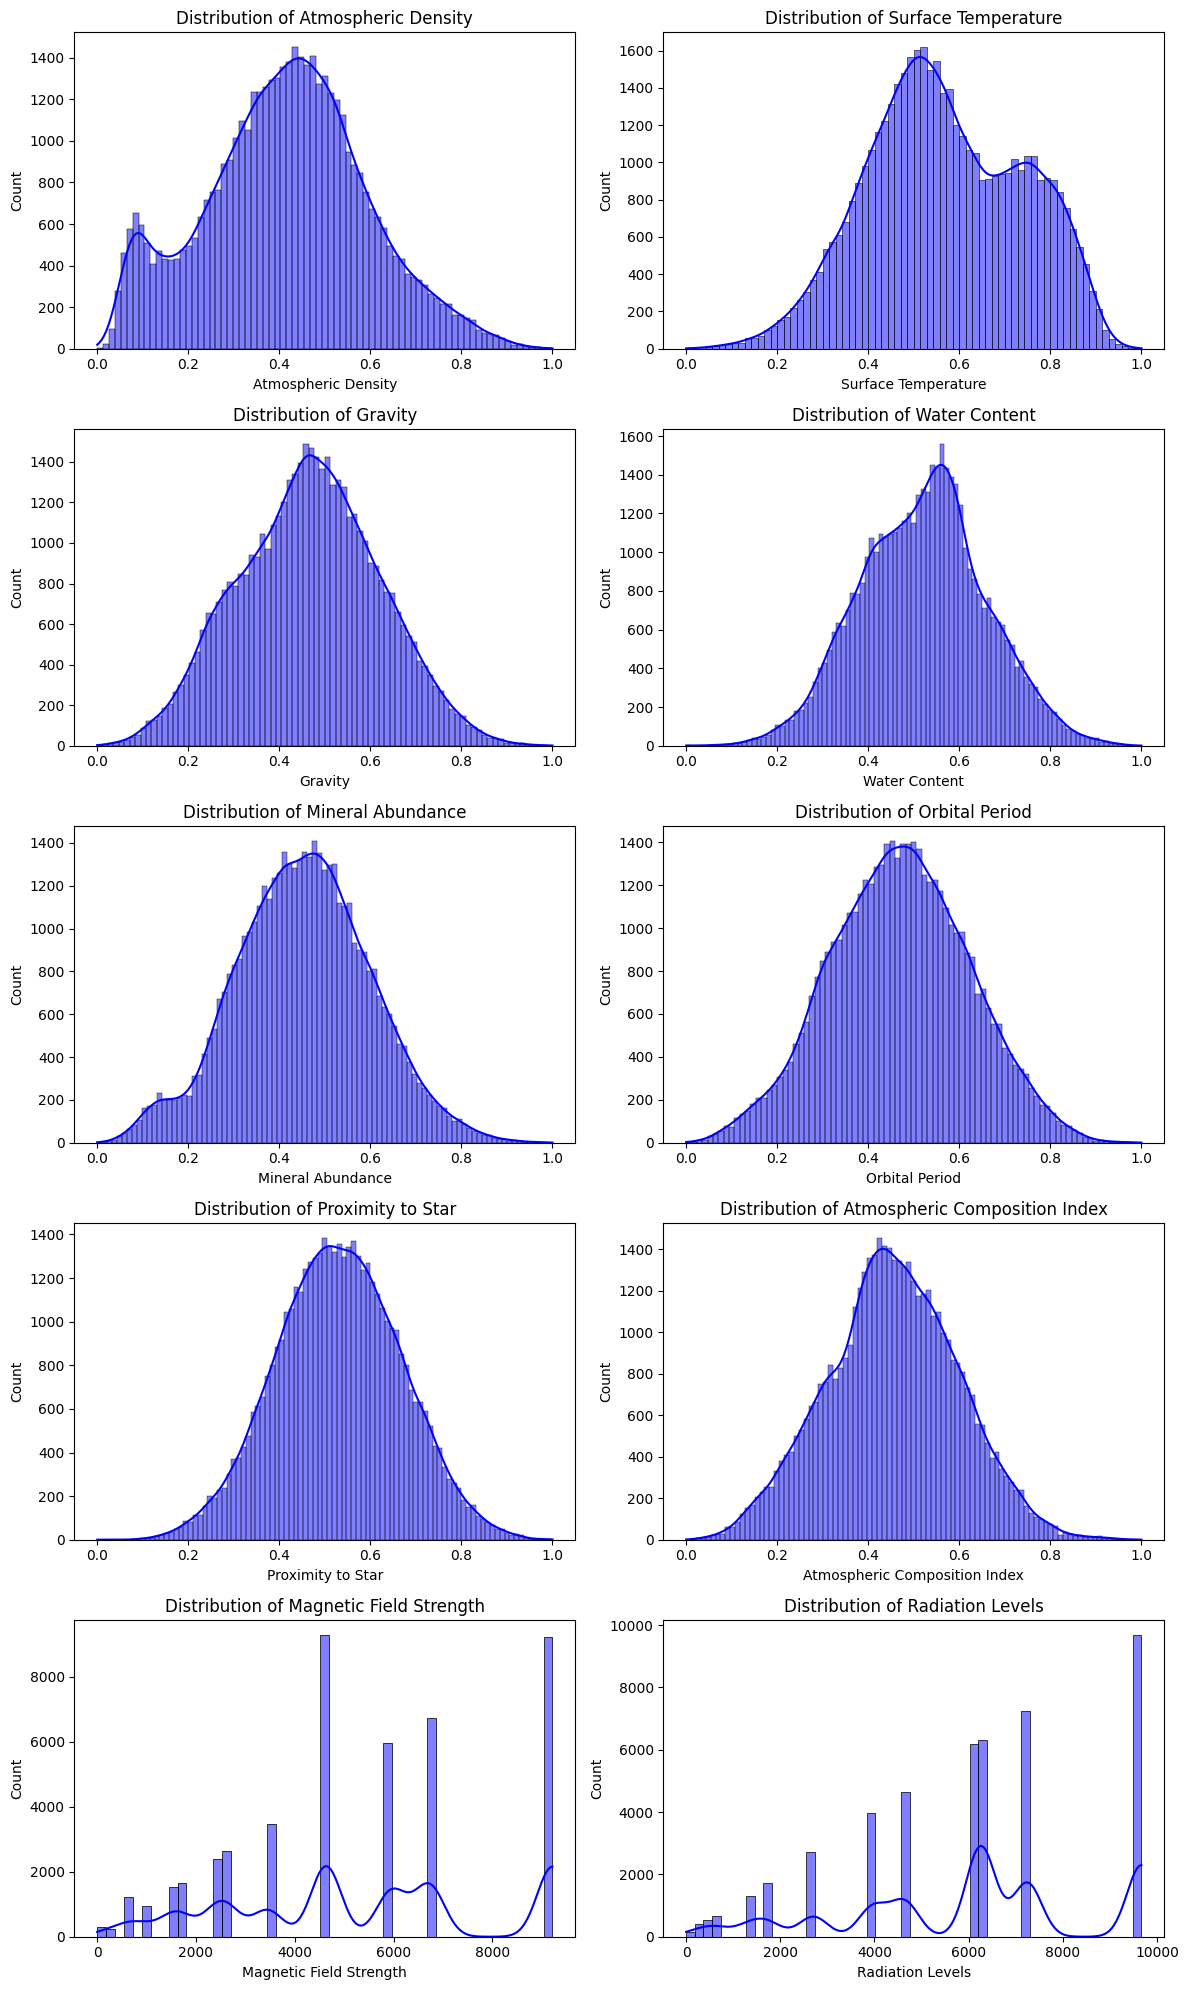

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index', 'Magnetic Field Strength', 'Radiation Levels']

num_colss = 2
num_rowss = math.ceil(len(columns) / num_colss)

fig, axes = plt.subplots(num_rowss, num_colss, figsize=(12, num_rowss * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(x_train[col], kde=True, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
def remove_outliers_sync(x, y, cols):
    mask = pd.Series(True, index=x.index)
    for col in cols:
        Q1 = x[col].quantile(0.25)
        Q3 = x[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mask &= (x[col] >= lower) & (x[col] <= upper)
    return x[mask], y[mask]

# Remove outliers and keep x and y in sync for training and testing sets
x_train_clean, y_train_clean = remove_outliers_sync(x_train, y_train, columns)
x_test_clean,  y_test_clean  = remove_outliers_sync(x_test, y_test, columns)


In [25]:
x_train = x_train_clean
x_test = x_test_clean
y_train = y_train_clean
y_test = y_test_clean

In [26]:
print(x_train_clean.shape)
print(x_test_clean.shape)
print(y_train_clean.shape)
print(y_test_clean.shape)

(44309, 10)
(11103, 10)
(44309,)
(11103,)


In [27]:
x_train['atmospheric pressure'] = x_train['Gravity']*x_train['Atmospheric Density']
x_train['Energy Recieved'] = x_train['Proximity to Star']*x_train['Orbital Period']
x_train['Water state'] = x_train['Water Content']*x_train['Surface Temperature']

x_test['atmospheric pressure'] = x_test['Gravity']*x_test['Atmospheric Density']
x_test['Energy Recieved'] = x_test['Proximity to Star']*x_test['Orbital Period']
x_test['Water state'] = x_test['Water Content']*x_test['Surface Temperature']

<ipython-input-27-df1e69907635>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['atmospheric pressure'] = x_train['Gravity']*x_train['Atmospheric Density']
<ipython-input-27-df1e69907635>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Energy Recieved'] = x_train['Proximity to Star']*x_train['Orbital Period']
<ipython-input-27-df1e69907635>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

In [28]:
x_train['Thermal Efficiency'] = x_train['Surface Temperature']/x_train['Proximity to Star']
x_train['Atmospheric Retention'] = x_train['Atmospheric Density']/x_train['Gravity']
x_train['Water phase indicator'] = x_train['Water Content']/x_train['Surface Temperature']

x_test['Thermal Efficiency'] = x_test['Surface Temperature']/x_test['Proximity to Star']
x_test['Atmospheric Retention'] = x_test['Atmospheric Density']/x_test['Gravity']
x_test['Water phase indicator'] = x_test['Water Content']/x_test['Surface Temperature']


<ipython-input-28-b913b539fec6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Thermal Efficiency'] = x_train['Surface Temperature']/x_train['Proximity to Star']
<ipython-input-28-b913b539fec6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Atmospheric Retention'] = x_train['Atmospheric Density']/x_train['Gravity']
<ipython-input-28-b913b539fec6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [29]:
x_train['Surface Temperature Polynomial'] = x_train['Surface Temperature']**2
x_train['Gravity Polynomial'] = x_train['Gravity']**2
x_train['Proximity to Star Polynomial'] = x_train['Proximity to Star']**2

x_test['Surface Temperature Polynomial'] = x_test['Surface Temperature']**2
x_test['Gravity Polynomial'] = x_test['Gravity']**2
x_test['Proximity to Star Polynomial'] = x_test['Proximity to Star']**2

In [30]:
x_train['rf1'] = x_train['Water Content']/x_train['Mineral Abundance']
x_train['rf2'] = x_train['Atmospheric Density']/x_train['Surface Temperature']
x_train['rf3'] = x_train['Gravity']/x_train['Orbital Period']

x_test['rf1'] = x_test['Water Content']/x_test['Mineral Abundance']
x_test['rf2'] = x_test['Atmospheric Density']/x_test['Surface Temperature']
x_test['rf3'] = x_test['Gravity']/x_test['Orbital Period']

In [31]:
x_train.sample(5)

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Atmospheric Composition Index,Magnetic Field Strength,Radiation Levels,...,Water state,Thermal Efficiency,Atmospheric Retention,Water phase indicator,Surface Temperature Polynomial,Gravity Polynomial,Proximity to Star Polynomial,rf1,rf2,rf3
2869,0.468294,0.687185,0.598432,0.446034,0.334209,0.538485,0.530547,0.709842,9216,4642,...,0.306508,1.295239,0.782535,0.649074,0.472224,0.358121,0.281480,1.334597,0.681467,1.111326
40506,0.335955,0.741377,0.495960,0.487115,0.193393,0.579011,0.564346,0.344117,9216,3970,...,0.361136,1.313692,0.677383,0.657041,0.549640,0.245976,0.318486,2.518783,0.453150,0.856564
56976,0.455803,0.584090,0.391864,0.477549,0.511466,0.491668,0.436448,0.624077,9216,7248,...,0.278932,1.338282,1.163165,0.817595,0.341161,0.153558,0.190487,0.933687,0.780364,0.797010
59667,0.343317,0.234188,0.374657,0.602760,0.543332,0.712701,0.685111,0.341736,9216,9672,...,0.141159,0.341825,0.916351,2.573827,0.054844,0.140368,0.469377,1.109378,1.465988,0.525686
59264,0.360033,0.876991,0.410121,0.356140,0.360971,0.478363,0.718856,0.417839,3454,9672,...,0.312331,1.219980,0.877871,0.406093,0.769113,0.168199,0.516755,0.986616,0.410532,0.857341


In [32]:
mask_train = np.isfinite(x_train).all(axis=1)
x_train = x_train[mask_train].reset_index(drop=True)
y_train = y_train[mask_train].reset_index(drop=True)

# For the testing set
mask_test = np.isfinite(x_test).all(axis=1)
x_test = x_test[mask_test].reset_index(drop=True)
y_test = y_test[mask_test].reset_index(drop=True)

xgboost

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score , recall_score , f1_score
from sklearn.model_selection import cross_val_score
#from bayes_opt import BayesianOptimization
import xgboost as xgb


In [35]:
print(x_train.shape)
print(y_train.shape)

(44309, 22)
(44309,)


In [36]:
y_train.sample(10)

,Prediction
28884,3.0
34973,0.0
2391,5.0
31686,5.0
38863,1.0
49,9.0
16756,7.0
30207,0.0
24125,2.0
3646,5.0


In [37]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(44309, 22)
(11103, 22)
(44309,)
(11103,)


In [38]:
import numpy as np

# Check for infinite values
print(np.isinf(x_train).sum())

# Check for very large values
print(np.max(x_train))

Atmospheric Density               0
Surface Temperature               0
Gravity                           0
Water Content                     0
Mineral Abundance                 0
Orbital Period                    0
Proximity to Star                 0
Atmospheric Composition Index     0
Magnetic Field Strength           0
Radiation Levels                  0
atmospheric pressure              0
Energy Recieved                   0
Water state                       0
Thermal Efficiency                0
Atmospheric Retention             0
Water phase indicator             0
Surface Temperature Polynomial    0
Gravity Polynomial                0
Proximity to Star Polynomial      0
rf1                               0
rf2                               0
rf3                               0
dtype: int64
9672.0


In [39]:
from sklearn.metrics import accuracy_score , classification_report

In [40]:
model = xgb.XGBClassifier(
        max_depth=int(10.608596766513095),
        learning_rate=0.0812716491083964,
        n_estimators=int(365.8535966918183),
        gamma=0.11991037254682146,
        min_child_weight=7.461081373768515,
        subsample=0.8162991052130569,
        colsample_bytree=0.6786078121721622,
        objective='multi:softmax',
        num_class=10,
        eval_metric=['mlogloss',  'merror']
)

model.fit(x_train , y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test , y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8040


In [ ]:
print(classification_report(y_test , y_pred))

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml



# Define evaluation set
eval_set = [(x_train, y_train), (x_test, y_test)]

# Train the model
modelxgb = xgb.XGBClassifier(
    n_estimators=500,  # Increase the number of boosting rounds
    eval_metric=['merror', 'mlogloss'],
    use_label_encoder=False,
    objective='multi:softmax',
    num_class=10,
    tree_method='gpu_hist'  # Enable GPU acceleration
)

modelxgb.fit(
    x_train,
    y_train,
    eval_set=eval_set,
    verbose=True
)

# Retrieve evaluation results
results = modelxgb.evals_result()
epochs = len(results['validation_0']['merror'])  # Changed 'error' to 'merror'
x_axis = range(epochs)

# Plot training and test error
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['merror'], label='Train Error')
plt.plot(x_axis, results['validation_1']['merror'], label='Test Error')
plt.plot(x_axis, results['validation_0']['mlogloss'], label='logloss')
plt.xlabel('Epoch')
plt.ylabel('Multi-class Error Rate')
plt.title('XGBoost: Training vs Test Error')
plt.legend()
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Initialize the XGBClassifier
model = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Generate learning curve data (using 5-fold cross-validation)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=x_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Compute mean scores across folds
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', marker='o')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation Accuracy', marker='o')
plt.xlabel('Number of Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve for XGBoost')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [41]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

def preprocess(data):
    # Imputing using KNN
    columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
               'Water Content', 'Mineral Abundance', 'Orbital Period',
               'Proximity to Star', 'Atmospheric Composition Index']

    knn = KNNImputer()
    data[columns] = knn.fit_transform(data[columns])

    # Frequency encoding for categorical columns
    freq_encode_cols = ['Radiation Levels', 'Magnetic Field Strength']

    for col in freq_encode_cols:
        freq_map = data[col].value_counts().to_dict()
        data[col] = data[col].map(freq_map)

    # Mode imputation for specific columns
    si_mode = SimpleImputer(strategy='most_frequent')
    data['Magnetic Field Strength'] = si_mode.fit_transform(data[['Magnetic Field Strength']])
    data['Radiation Levels'] = si_mode.fit_transform(data[['Radiation Levels']])

    # Power transformation
    pt = PowerTransformer(method='yeo-johnson')
    for col in columns:
        data[col] = pt.fit_transform(data[[col]])

    # MinMax scaling
    mms = MinMaxScaler()

    # Store original categorical columns
    train_magnetic = data['Magnetic Field Strength'].copy()
    train_radiation = data['Radiation Levels'].copy()

    # Transform numerical columns
    data_scaled = mms.fit_transform(data[columns])

    # Convert back to DataFrame with proper indices
    data = pd.DataFrame(data_scaled, columns=columns, index=train_magnetic.index)

    # Add back categorical columns
    data['Magnetic Field Strength'] = train_magnetic
    data['Radiation Levels'] = train_radiation

    # Feature engineering
    data['atmospheric pressure'] = data['Gravity'] * data['Atmospheric Density']
    data['Energy Recieved'] = data['Proximity to Star'] * data['Orbital Period']
    data['Water state'] = data['Water Content'] * data['Surface Temperature']

    data['Thermal Efficiency'] = data['Surface Temperature'] / data['Proximity to Star']
    data['Atmospheric Retention'] = data['Atmospheric Density'] / data['Gravity']
    data['Water phase indicator'] = data['Water Content'] / data['Surface Temperature']

    data['Surface Temperature Polynomial'] = data['Surface Temperature']**2
    data['Gravity Polynomial'] = data['Gravity']**2
    data['Proximity to Star Polynomial'] = data['Proximity to Star']**2

    data['rf1'] = data['Water Content'] / data['Mineral Abundance']
    data['rf2'] = data['Atmospheric Density'] / data['Surface Temperature']
    data['rf3'] = data['Gravity'] / data['Orbital Period']

    # Remove rows with infinite values
    mask = np.isfinite(data).all(axis=1)
    data = data[mask].reset_index(drop=True)

    print("Processed data shape:", data.shape)
    return data

# Usage
data = pd.read_csv('/content/drive/MyDrive/cosmic_test.csv')
processed_data = preprocess(data)

Processed data shape: (9995, 22)


In [43]:
predictions=model.predict(processed_data)

In [48]:
predictions_csv = pd.DataFrame(predictions)
predictions_csv.to_csv('blueberry_predictions.csv')